In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))  # Go up one directory

from llm_provider import LLM_provider
llm=LLM_provider()
model=llm.get_llm()
model.invoke("hi")



ModuleNotFoundError: No module named 'langchain_openai'

In [2]:
from langgraph.types import Command

In [3]:
def add_number(state):
    result=state["num1"]+state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply",update={"sum":result})

In [4]:
state={"num1":10,"num2":20}

In [5]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

Creating one dummy multiagent
it is for network/collab multiagent

In [6]:
from langchain_core.tools import tool

In [7]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication Agent for help"""

In [8]:
@tool
def transfer_to_addition_expert():
    """Ask addition Agent for help"""

In [9]:
llm_with_tool=model.bind_tools([transfer_to_addition_expert])

In [10]:
response=llm_with_tool.invoke("hi")

In [11]:
response

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 42, 'total_tokens': 53, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_7a7fd0eb44', 'id': 'chatcmpl-DCdr9fqVdli4f8hVt7z9qbITbpGuk', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'p

In [12]:
"""AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 42, 'total_tokens': 53, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_b9041e10b4', 'id': 'chatcmpl-D8euMOuozjwLcOXipGhiFQX6oBqMn', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protected_material_code': {'detected': False, 'filtered': False}, 'protected_material_text': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}, id='run--eeb777bb-5d0b-4ed1-b11b-22c1d5f75b6d-0', usage_metadata={'input_tokens': 42, 'output_tokens': 11, 'total_tokens': 53, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})"""

"AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 42, 'total_tokens': 53, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_b9041e10b4', 'id': 'chatcmpl-D8euMOuozjwLcOXipGhiFQX6oBqMn', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, '

In [13]:
response.content

'Hello! How can I help you today?'

In [14]:
response.tool_calls

[]

In [15]:
response=llm_with_tool.invoke("what is 2+2? use tools")

In [16]:
response.tool_calls

[{'name': 'transfer_to_addition_expert',
  'args': {},
  'id': 'call_bGnhQJD3veiXbXvZ1lhTQgBC',
  'type': 'tool_call'}]

In [17]:
response.content

''

In [18]:
system_prompt=(
    "You are an addition expert, you can ask the multiplication expert for help with multiplication."
    "Always do your portion of calculation before the handoff."
    )

In [19]:
system_prompt

'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'

In [20]:
messages=[{"role":"system","content":system_prompt}]+["can you tell me the addition of 2 and 2?"]

In [21]:
messages

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [22]:
from typing_extensions import Literal
from langgraph.graph import MessagesState,StateGraph, START,END
from langgraph.prebuilt import ToolNode

In [23]:
@tool
def add(a:int , b:int):
    """Add two numbers"""
    return a+b

@tool
def multiply(a:int,b:int):
    """Multiply two numbers"""
    return a*b

add_tool_node = ToolNode([add])
multiply_tool_node = ToolNode([multiply])

In [24]:
##Agent1
def additional_expert(state:MessagesState)->Command[Literal["multiplication_expert", "add_tools","__end__"]]:
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = model.bind_tools([add,transfer_to_multiplication_expert]).invoke(messages)
    # print("WTF",ai_msg)
    if len(ai_msg.tool_calls)>0:
        tool_name=ai_msg.tool_calls[-1]['name']
        if tool_name=='transfer_to_multiplication_expert':
            tool_call_id=ai_msg.tool_calls[-1]['id']
            tool_msg={
                "role":"tool",
                "content":"Succesfully Transfered",
                "tool_call_id": tool_call_id,
            }

            return Command(goto="multiplication_expert",update={"messages":[ai_msg,tool_msg]})
        else:
            return Command(goto="add_tools",update={"messages":[ai_msg]})
    
    return {"messages": [ai_msg]}

In [25]:
##Agent2
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert","multiply_tools","__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = model.bind_tools([multiply,transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_name=ai_msg.tool_calls[-1]['name']
        if tool_name=='transfer_to_addition_expert':
            tool_call_id = ai_msg.tool_calls[-1]["id"]
            tool_msg = {
                "role": "tool",
                "content": "Successfully transferred",
                "tool_call_id": tool_call_id,
            }
            return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
        else:
            return Command(goto="multiply_tools", update={"messages": [ai_msg]})
    return {"messages": [ai_msg]}

In [26]:
graph=StateGraph(MessagesState)

In [27]:
graph.add_node("additional_expert",additional_expert)
graph.add_node("multiplication_expert",multiplication_expert)
graph.add_node("add_tools", add_tool_node)
graph.add_node("multiply_tools", multiply_tool_node)

In [28]:
graph.add_edge(START, "additional_expert")
graph.add_edge("add_tools", "additional_expert")          
graph.add_edge("multiply_tools", "multiplication_expert") 

In [29]:
app=graph.compile()

In [30]:
result=app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

In [31]:
result

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='6245ee96-5ad9-4a26-b061-921341395246'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_KnF1G6lC0hmmuiocDnvAh6sq', 'function': {'arguments': '{"a":3,"b":5}', 'name': 'add'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 107, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_b9041e10b4', 'id': 'chatcmpl-DCdrCs9M9HBNG362WTY3dOTct5hxx', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self

In [32]:
result['messages'][-1].content

'The result of (3 + 5) * 12 is 96.'

In [33]:
from langchain_experimental.utilities import PythonREPL

In [34]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()
search_tool.invoke("who is current pm of uk?")

"The prime minister of the United Kingdom is the principal minister of the crown of His Majesty's Government, and the head of the British Cabinet. Time in UK – Looking for the current time and date in the UK . Then you’re at the right place. UK Time Now. Our websites are useful for business travelers or people who have businesses in the United Kingdom and frequently travel to the UK . is the principal government figure in the House of Commons. Current role holder. The Rt Hon Sir Keir Starmer KCB KC MP. Sir Keir Starmer became Prime Minister on 5 July 2024. Cities Countries GMT time UTC time AM and PM .It may also be of great use for those who are often traveling. This time difference calculator takes into account the DST changes and provides you with necessary information on time zones. United Kingdom time zone and map with current time in the largest cities."

In [35]:
repl=PythonREPL()

In [36]:
code="""
x=5
y=x*2
print(y)
"""

In [37]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'10\n'

In [38]:
from typing import Annotated

In [39]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [40]:
python_repl_tool

StructuredTool(name='python_repl_tool', description='Use this to execute python code. If you want to see the output of a value,\n    you should print it out with `print(...)`. This is visible to the user.', args_schema=<class 'langchain_core.utils.pydantic.python_repl_tool'>, func=<function python_repl_tool at 0x000002809DE83880>)

In [41]:
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x=5
y=x*2
print(y)

\`\`\`
Stdout: 10


If you have completed all tasks, respond with FINAL ANSWER.


In [42]:
# from langgraph.prebuilt import create_react_agent
from langgraph.prebuilt.chat_agent_executor import create_react_agent

In [43]:
def make_system_prompt(instruction:str)->str:
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [44]:
from langchain_core.messages import BaseMessage

In [45]:
def get_next_node(last_message:BaseMessage,goto:str):
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

In [46]:
from langchain_core.messages import HumanMessage

In [47]:
# agent 1
def research_node(state:MessagesState)->Command[Literal["chart_generator",END]]:
    research_agent=create_react_agent(
        model,
        tools=[search_tool],
        prompt=make_system_prompt("You can only do research. You are workign with a chart generator colleague")
    )

    result=research_agent.invoke(state)

    goto=get_next_node(result["messages"][-1],"chart_generator")

    result["messages"][-1]= HumanMessage(content=result["messages"][-1].content,name="researcher")

    return Command(update={"messages":result["messages"]},goto=goto)

In [48]:
def chart_node(state:MessagesState)->Command[Literal["researcher",END]]:
    chart_agent=create_react_agent(
        model,
        tools=[python_repl_tool],
        prompt=make_system_prompt("You can only generate charts. You are working with a researcher colleague")
    )
    result=chart_agent.invoke(state)

    goto=get_next_node(result["messages"][-1],"researcher")

    result["messages"][-1]= HumanMessage(content=result["messages"][-1].content,name="chart_generator")

    return Command(update={"messages":result["messages"]},goto=goto)

In [49]:
workflow=StateGraph(MessagesState)

In [50]:
workflow.add_node("researcher",research_node)
workflow.add_node("chart_generator",chart_node)

In [51]:
workflow.add_edge(START,"researcher")

In [52]:
app=workflow.compile()

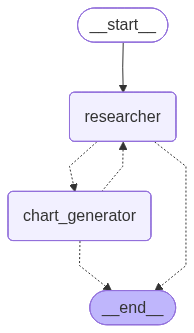

In [53]:
app

Matplotlib is building the font cache; this may take a moment.


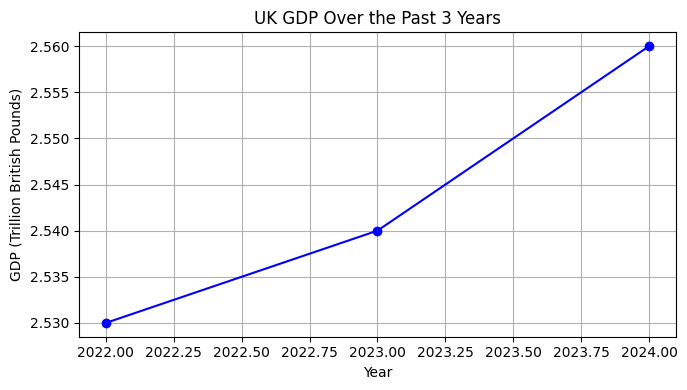

{'messages': [HumanMessage(content="get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='08ca1817-3585-487f-8b17-4c699b52d7ff'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_1zySN2q6HCNQM6w3Su6LGxw1', 'function': {'arguments': '{"query":"UK GDP for the past 3 years"}', 'name': 'duckduckgo_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 200, 'total_tokens': 225, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_b9041e10b4', 'id': 'chatcmpl-DCdtcwNVGuclFf2AkhAj8dYNCQcTw', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': 

In [56]:
app.invoke({"messages": ["get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish."]})